# Phase 3 — Exploratory Data Analysis
Competition: Playground Series S6E7 — Predicting Student Health Risk  
Target: `health_condition` (at-risk / unhealthy / fit)  
Metric: **Balanced accuracy**

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load & first look

In [2]:
train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (2000, 13)
Test shape:  (500, 12)


,id,age,gender,height_cm,weight_kg,bmi,sleep_hours,physical_activity_hours,stress_level,diet_quality,screen_time_hours,academic_pressure,health_condition
0,1,21,Male,178.1,67.5,21.3,5.8,2.1,High,Poor,6.3,Low,unhealthy
1,2,18,Female,181.4,59.1,18.0,6.7,2.3,Moderate,Good,5.9,Moderate,fit
2,3,25,Male,160.6,84.1,32.6,5.4,0.9,Moderate,Good,6.5,Low,at-risk
3,4,22,Female,163.1,65.2,24.5,9.7,7.3,High,Poor,1.0,Moderate,unhealthy
4,5,19,Male,180.3,50.7,15.6,9.5,1.4,Low,Average,1.9,Moderate,unhealthy


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2000 non-null   int64  
 1   age                      2000 non-null   int64  
 2   gender                   2000 non-null   object 
 3   height_cm                2000 non-null   float64
 4   weight_kg                2000 non-null   float64
 5   bmi                      2000 non-null   float64
 6   sleep_hours              2000 non-null   float64
 7   physical_activity_hours  2000 non-null   float64
 8   stress_level             2000 non-null   object 
 9   diet_quality             2000 non-null   object 
 10  screen_time_hours        2000 non-null   float64
 11  academic_pressure        2000 non-null   object 
 12  health_condition         2000 non-null   object 
dtypes: float64(6), int64(2), object(5)
memory usage: 203.3+ KB


## 2. Missing values

In [4]:
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (train.isnull().mean() * 100).round(1).sort_values(ascending=False)
pd.concat([missing, missing_pct], axis=1, keys=['count', '%']).head(20)

,count,%
id,0,0.0
age,0,0.0
gender,0,0.0
height_cm,0,0.0
weight_kg,0,0.0
bmi,0,0.0
sleep_hours,0,0.0
physical_activity_hours,0,0.0
stress_level,0,0.0
diet_quality,0,0.0


## 3. Target distribution — critical for balanced_accuracy metric

health_condition
fit          738
unhealthy    688
at-risk      574
Name: count, dtype: int64

Class proportions:
health_condition
fit          0.369
unhealthy    0.344
at-risk      0.287
Name: proportion, dtype: float64


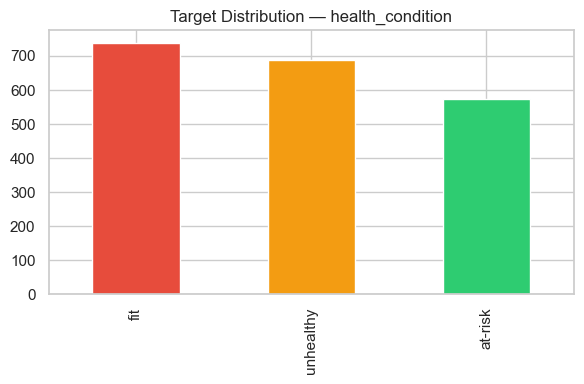

In [5]:
print(train['health_condition'].value_counts())
print('\nClass proportions:')
print(train['health_condition'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
train['health_condition'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#f39c12','#2ecc71'])
ax.set_title('Target Distribution — health_condition')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../models/target_distribution.png', dpi=100)
plt.show()

**Finding:** Record class balance / imbalance here. If any class < 20% → use `class_weight='balanced'` in all sklearn models.

## 4. Univariate exploration — numeric features

In [6]:
num_cols = train.select_dtypes(include='number').columns.drop('id', errors='ignore').tolist()
print('Numeric columns:', num_cols)
train[num_cols].describe()

Numeric columns: ['age', 'height_cm', 'weight_kg', 'bmi', 'sleep_hours', 'physical_activity_hours', 'screen_time_hours']


,age,height_cm,weight_kg,bmi,sleep_hours,physical_activity_hours,screen_time_hours
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,19.899500,167.666450,64.583300,23.220300,7.020150,3.040850,5.073650
std,3.181896,10.082186,12.066051,5.202898,1.554135,3.013117,1.977153
min,15.000000,136.300000,26.900000,9.000000,3.000000,0.000000,1.000000
25%,17.000000,160.900000,56.575000,19.700000,5.900000,0.900000,3.700000
50%,20.000000,167.650000,64.500000,22.800000,7.000000,2.000000,5.100000
75%,23.000000,174.400000,72.825000,26.400000,8.100000,4.300000,6.400000
max,25.000000,207.300000,102.400000,47.900000,11.000000,15.000000,11.600000


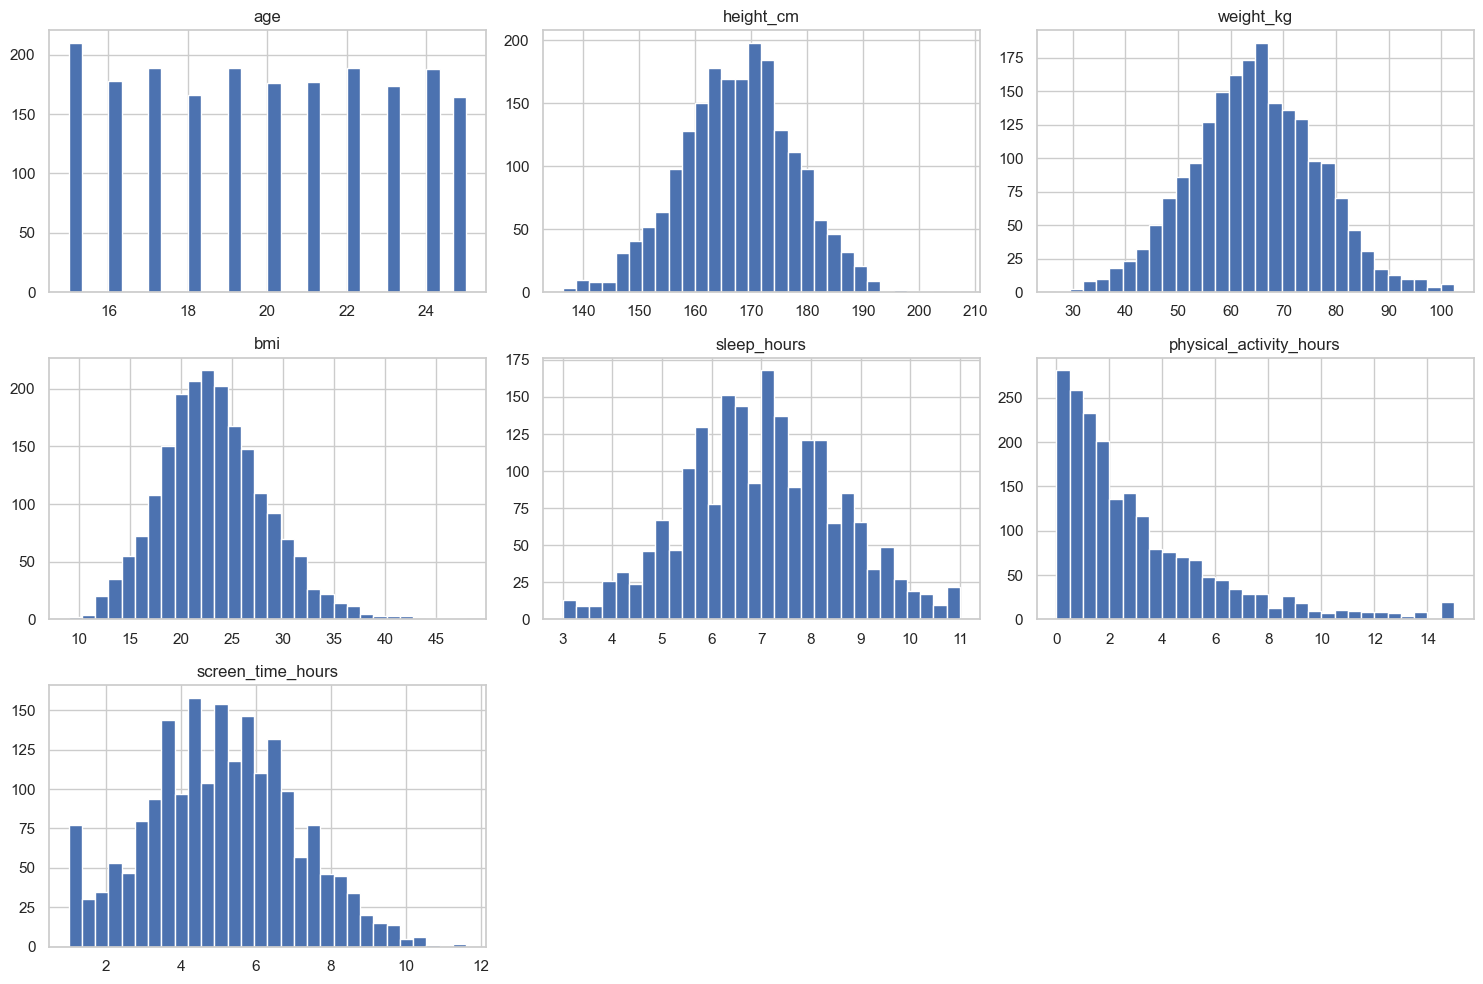

In [7]:
train[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.savefig('../models/numeric_histograms.png', dpi=100)
plt.show()

## 5. Correlation heatmap

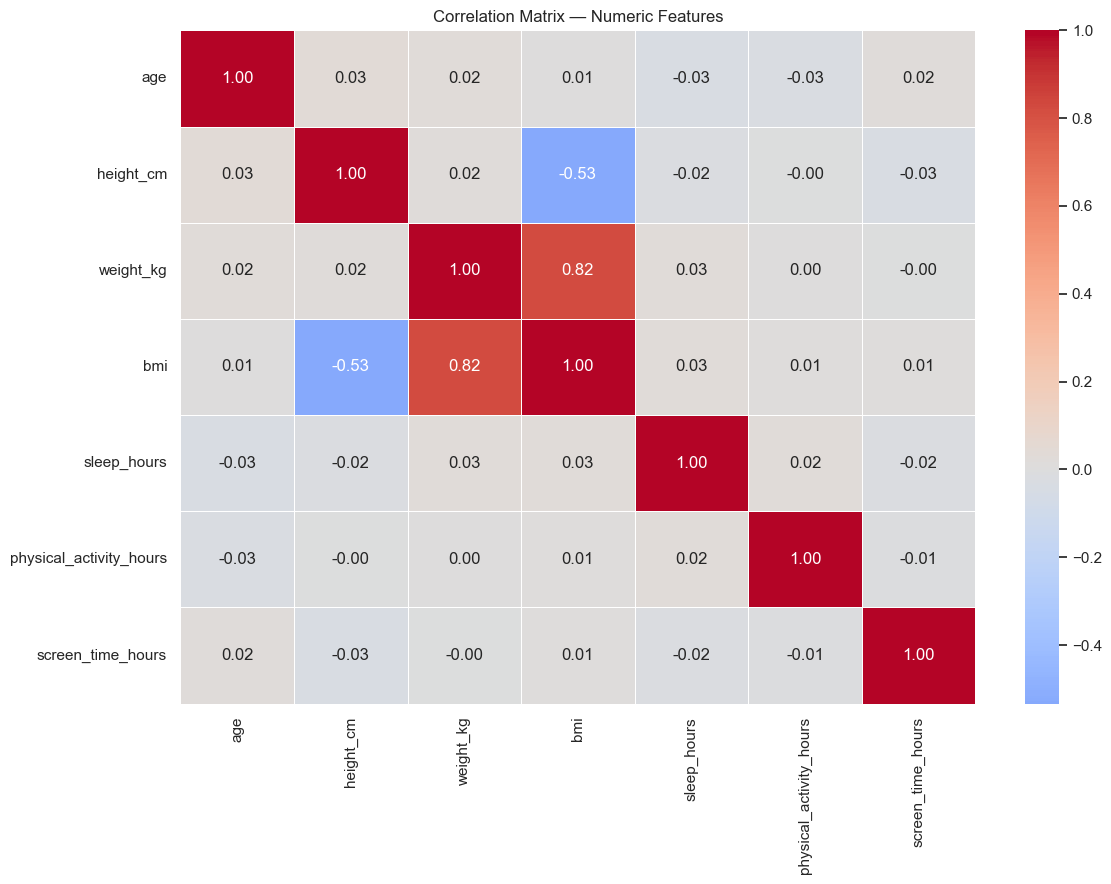

In [8]:
corr = train[num_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('../models/correlation_heatmap.png', dpi=100)
plt.show()

## 6. Feature vs target (numeric)

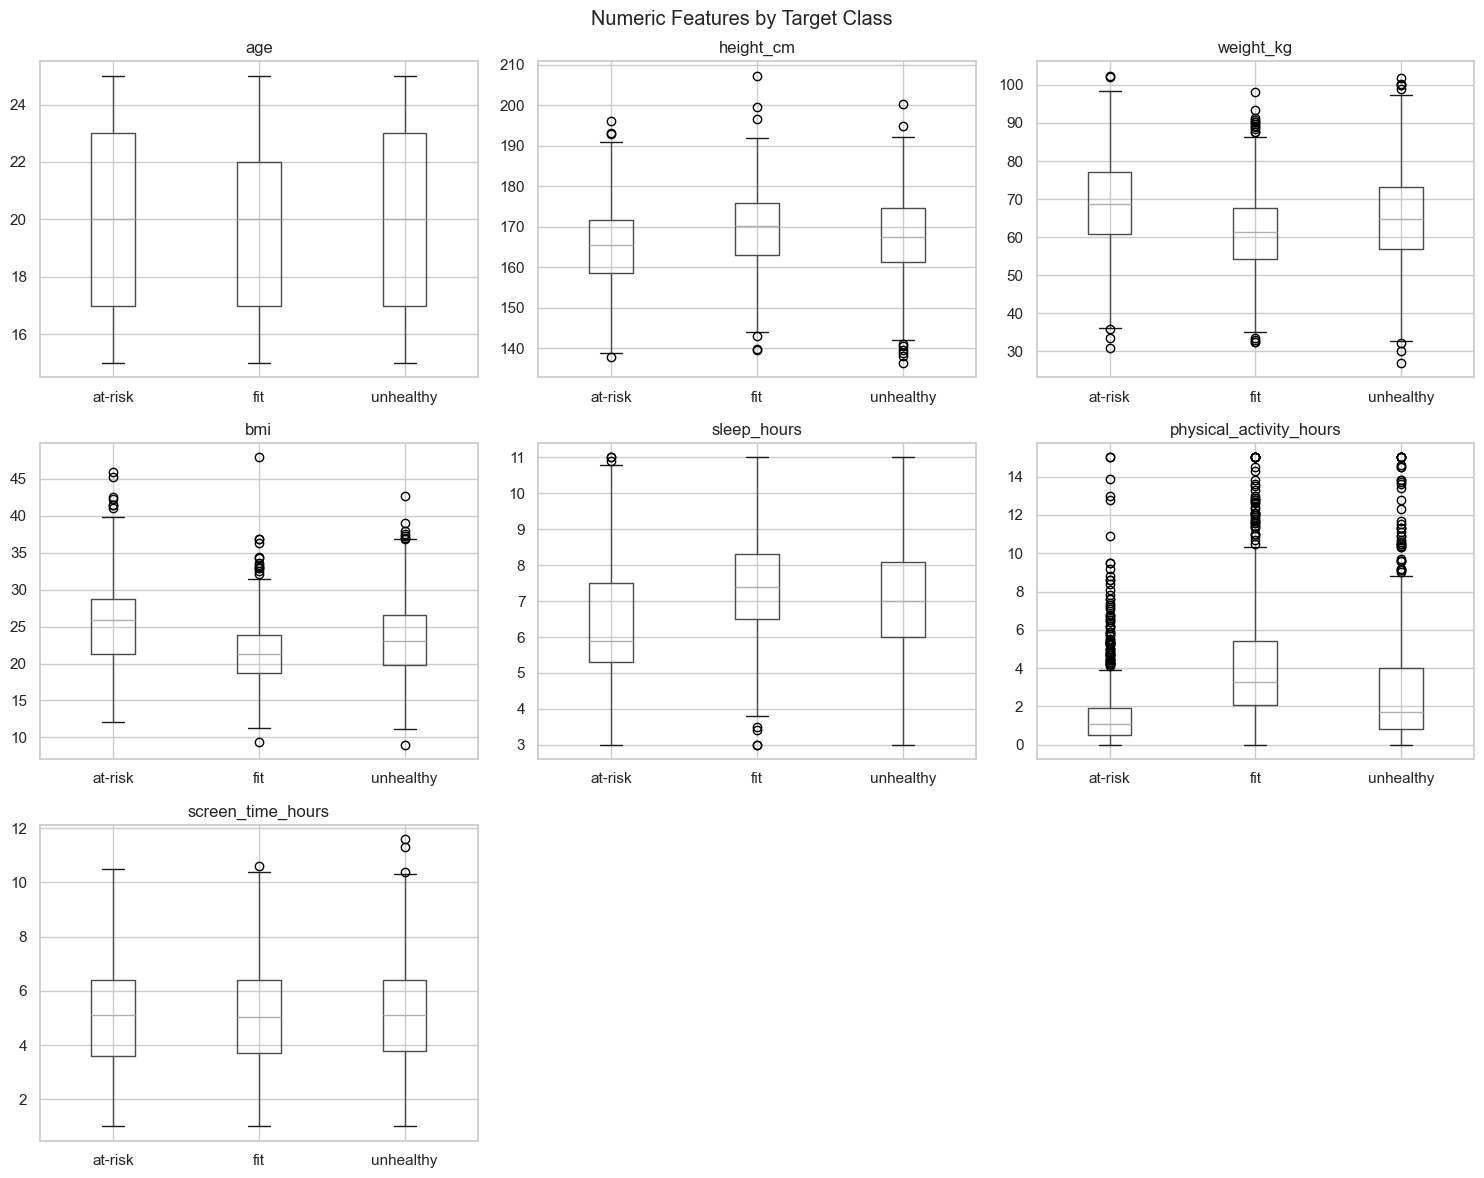

In [9]:
fig, axes = plt.subplots(nrows=(len(num_cols)+2)//3, ncols=3,
                          figsize=(15, 4*((len(num_cols)+2)//3)))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    train.boxplot(column=col, by='health_condition', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numeric Features by Target Class')
plt.tight_layout()
plt.savefig('../models/features_vs_target.png', dpi=100)
plt.show()

## 7. Categorical features

In [10]:
cat_cols = train.select_dtypes(include='object').columns.drop('health_condition', errors='ignore').tolist()
print('Categorical columns:')
for c in cat_cols:
    print(f'  {c}: {train[c].nunique()} unique values → {train[c].unique()[:5]}')

Categorical columns:
  gender: 3 unique values → ['Male' 'Female' 'Other']
  stress_level: 3 unique values → ['High' 'Moderate' 'Low']
  diet_quality: 3 unique values → ['Poor' 'Good' 'Average']
  academic_pressure: 3 unique values → ['Low' 'Moderate' 'High']


In [11]:
for col in cat_cols:
    ct = pd.crosstab(train[col], train['health_condition'], normalize='index').round(3)
    print(f'\n{col}:')
    display(ct)


gender:


health_condition,at-risk,fit,unhealthy
gender,,,
Female,0.283,0.384,0.333
Male,0.289,0.359,0.352
Other,0.309,0.309,0.383



stress_level:


health_condition,at-risk,fit,unhealthy
stress_level,,,
High,0.504,0.201,0.295
Low,0.230,0.404,0.366
Moderate,0.232,0.417,0.351



diet_quality:


health_condition,at-risk,fit,unhealthy
diet_quality,,,
Average,0.217,0.441,0.341
Good,0.234,0.407,0.359
Poor,0.486,0.180,0.334



academic_pressure:


health_condition,at-risk,fit,unhealthy
academic_pressure,,,
High,0.304,0.365,0.331
Low,0.284,0.390,0.326
Moderate,0.280,0.363,0.356


## 8. Outlier detection (IQR)

In [12]:
Q1 = train[num_cols].quantile(0.25)
Q3 = train[num_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_count = ((train[num_cols] < (Q1 - 1.5*IQR)) | (train[num_cols] > (Q3 + 1.5*IQR))).sum()
print('Outlier counts per feature:')
print(outlier_count.sort_values(ascending=False))

Outlier counts per feature:
physical_activity_hours    95
bmi                        28
height_cm                  18
weight_kg                  14
screen_time_hours           4
age                         0
sleep_hours                 0
dtype: int64


## 9. EDA Findings Summary

**Fill this in after running the cells above:**

1. **Class balance:** `health_condition` distribution is ________ → will use `class_weight='balanced'`
2. **Missing values:** Columns with >5% missing: ________ → strategy: median/mode impute
3. **Skewed features:** ________ → may clip or log-transform
4. **High correlation:** ________ correlated with ________ → drop one
5. **Categorical cardinality:** All cats have low cardinality → OneHotEncoder is fine